In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import re
import numpy as np

# Analyse de corrélation entre les articles scrappés et le sondage Politbarometer
## Transformer les sondage en apercu annuel et normaliser

In [76]:
df = pd.read_stata('data/Politbarometer/dataset_cumul_1977_reduced.dta',convert_categoricals=False)
df

,index,v1,v2,Version,doi,v3,v4,V4a,v5,v6,...,v68,v71,v72,v73,v74,v75,v77,v78,v80,V81
0,345603,2391,2001.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,1,2000,1,1,1,...,0,0,2,1,4,12,8,0.520,1,0.144
1,345604,2391,2002.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,1,2000,1,1,2,...,0,0,10,0,4,12,8,0.550,1,0.153
2,345605,2391,2003.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,1,2000,1,1,18,...,1,4,10,0,1,12,8,1.000,1,0.277
3,345607,2391,2011.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,1,2000,1,1,6,...,0,0,8,2,4,17,7,0.640,1,0.178
4,345608,2391,2012.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,1,2000,1,1,2,...,0,0,1,3,4,15,1,0.950,1,0.264
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
568019,1046811,2391,501623.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,12,2022,2,1,2,...,0,4,1,3,1,8,4,0.917,50,0.917
568020,1046812,2391,501624.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,12,2022,1,1,6,...,0,0,8,2,4,15,5,0.461,50,0.223
568021,1046815,2391,501627.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,12,2022,2,1,4,...,0,4,6,2,3,1,1,0.596,50,0.596
568022,1046816,2391,501628.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,12,2022,1,1,38,...,0,4,10,0,4,13,5,1.969,50,0.954


In [77]:
problemes_survey_df = df[['v4', 'v33']]
#votes_partie_df.loc[:,'v33'] = votes_partie_df['v33'].apply(lambda x: dict_plus_grand_problemes[x] if x in dict_plus_grand_problemes.keys() else x)

problemes_survey_df = problemes_survey_df[~problemes_survey_df['v33'].isin([0,998,999])]

total = int(problemes_survey_df['v33'].count())


pb_percentage = pd.DataFrame(problemes_survey_df.groupby('v33').size() / total)
top_20_problems = list(pb_percentage.sort_values(by=0,ascending=False)[0:20].reset_index()['v33'])
problemes_survey_df = problemes_survey_df[problemes_survey_df['v33'].isin(top_20_problems)]


total_votes_per_year = pd.DataFrame(problemes_survey_df.groupby(by=['v4']).size())

total_votes_per_year = total_votes_per_year.reset_index()


In [ ]:
print(problemes_survey_df)
problemes_survey_df = pd.DataFrame(problemes_survey_df.groupby(by=['v4','v33']).size())

problemes_survey_df = problemes_survey_df.reset_index()
#votes_partie_df[0] = votes_partie_df[0] / total_votes_per_year[0]
problemes_survey_df = problemes_survey_df.set_index('v4')
total_votes_per_year = total_votes_per_year.set_index('v4')
problemes_survey_df['total'] =  total_votes_per_year
print(problemes_survey_df)
problemes_survey_df['vote percentage'] = problemes_survey_df[0] / problemes_survey_df['total'] 
#problemes_survey_df['vote percentage'] = (problemes_survey_df[0]-problemes_survey_df[0].min())/(problemes_survey_df[0].max()-problemes_survey_df[0].min())


problemes_survey_df = problemes_survey_df.reset_index()

          v4  v33
0       2000   27
1       2000   14
2       2000   27
3       2000   14
4       2000   27
...      ...  ...
568011  2022   30
568012  2022   15
568013  2022   77
568016  2022   15
568019  2022   15

[476483 rows x 2 columns]
      v33     0  total
v4                    
2000    1   773  14609
2000    5   157  14609
2000    7    43  14609
2000   10   376  14609
2000   13   287  14609
...   ...   ...    ...
2022   58    51   7828
2022   66   356   7828
2022   77   426   7828
2022   78    50   7828
2022  134  1559   7828

[424 rows x 3 columns]
       v4  v33     0  total  vote percentage
0    2000    1   773  14609         0.052913
1    2000    5   157  14609         0.010747
2    2000    7    43  14609         0.002943
3    2000   10   376  14609         0.025738
4    2000   13   287  14609         0.019645
..    ...  ...   ...    ...              ...
419  2022   58    51   7828         0.006515
420  2022   66   356   7828         0.045478
421  2022   77   426   7828  

In [79]:
data_lines = []
for year in range(2000,2023):
    data_line = []
    data_line.append(year)
    for question_code in top_20_problems:
        pc = problemes_survey_df[(problemes_survey_df['v4'] == year) & (problemes_survey_df['v33'] == question_code)]['vote percentage']
        if(len(pc) > 0):
            pc = float(pc.iloc[0])
        else:
            pc = 0
        data_line.append(pc)
    data_lines.append(data_line)
df_survey = pd.DataFrame(data_lines)
df_survey = df_survey.set_axis(['Year'] + top_20_problems,axis = 1)
print(top_20_problems)
df_survey = df_survey.set_index('Year')
df_survey

[14, 54, 13, 27, 55, 77, 1, 134, 117, 30, 15, 5, 66, 20, 19, 56, 10, 7, 58, 78]


,14,54,13,27,55,77,1,134,117,30,15,5,66,20,19,56,10,7,58,78
Year,,,,,,,,,,,,,,,,,,,,
2000,0.618249,0.044904,0.019645,0.066466,0.002396,0.008967,0.052913,0.000000,0.000000,0.008488,0.015333,0.010747,0.017797,0.006845,0.011500,0.005613,0.025738,0.002943,0.067150,0.014306
2001,0.641644,0.033634,0.047201,0.050776,0.022423,0.010236,0.037209,0.000000,0.000000,0.012349,0.015680,0.011618,0.016736,0.010724,0.015355,0.004062,0.013161,0.004387,0.041921,0.010886
2002,0.733996,0.019329,0.072075,0.044589,0.012408,0.006921,0.010925,0.000000,0.000000,0.013743,0.006822,0.009195,0.013397,0.005240,0.011914,0.008404,0.017895,0.002571,0.002966,0.007613
2003,0.679825,0.005730,0.094548,0.055511,0.000080,0.007362,0.036928,0.000000,0.000000,0.007481,0.002069,0.005889,0.020175,0.023558,0.007282,0.016395,0.026582,0.001592,0.000836,0.008158
2004,0.689185,0.010619,0.075157,0.058856,0.001215,0.010776,0.027821,0.000000,0.000000,0.012461,0.000000,0.008464,0.015596,0.034522,0.009208,0.015635,0.015909,0.002782,0.002312,0.009483
2005,0.798624,0.005384,0.051211,0.042776,0.000509,0.009273,0.012833,0.000000,0.000000,0.009064,0.002303,0.012713,0.009273,0.004936,0.008794,0.013222,0.008735,0.002363,0.001107,0.006880
2006,0.724102,0.014163,0.032526,0.036973,0.000371,0.014246,0.024539,0.000000,0.000000,0.017210,0.002800,0.018239,0.000124,0.050972,0.018239,0.011281,0.021492,0.003417,0.002182,0.007123
2007,0.565179,0.016193,0.026096,0.044521,0.001420,0.038920,0.035065,0.000000,0.000000,0.027435,0.043628,0.048417,0.020820,0.032102,0.041477,0.008320,0.019683,0.018547,0.003328,0.008847
2008,0.346403,0.015092,0.055897,0.061647,0.000479,0.064322,0.033938,0.000000,0.112753,0.038529,0.020762,0.122215,0.015172,0.016250,0.027350,0.006189,0.027509,0.022319,0.002316,0.010860


### Lire les dataframes scrappées

In [80]:
first = True
base_path = 'ScrappingJournaux/scrapping/de'
for file in os.listdir(base_path):
    with open(os.path.join(base_path,file), 'rb') as f:
        answer_code = int(re.findall('^\d+',file)[0])
        df = pd.read_pickle(f)
        if first:
            dfs_faz_all = pd.DataFrame(df['faz'].copy())
            dfs_faz_all = dfs_faz_all.rename(columns={'faz':answer_code})
            dfs_taz_all = pd.DataFrame(df['taz'].copy())
            dfs_taz_all = dfs_faz_all.rename(columns={'taz':answer_code})
            first = False
        else:
            dfs_faz_all[answer_code] = df['faz']
            dfs_taz_all[answer_code] = df['taz']

# normalize
dfs_faz_all = (dfs_faz_all-dfs_faz_all.min())/(dfs_faz_all.max()-dfs_faz_all.min())

dfs_taz_all = (dfs_taz_all-dfs_taz_all.min())/(dfs_taz_all.max()-dfs_taz_all.min())
#dfs_faz_all = dfs_faz_all.reset_index()
print(dfs_faz_all.columns.values)

[ 55  30  56  13  23  20 117  10  27   1  19  14 134   5  77  54  58  15
  53]


### Calcul de corrélation

In [81]:
taz_corr = df_survey.corrwith(dfs_taz_all,axis = 0)
taz_corr

14     0.872910
54     0.833342
13     0.393049
27     0.127819
55     0.316684
77     0.573092
1      0.199801
134    0.994409
117    0.969076
30    -0.285957
15     0.668730
5      0.149650
20    -0.131521
19    -0.098316
56     0.867902
10     0.385526
58    -0.368439
7           NaN
23          NaN
53          NaN
66          NaN
78          NaN
dtype: float64

In [82]:
faz_corr = df_survey.corrwith(dfs_faz_all, axis = 0)

In [83]:
corr_df = pd.DataFrame({"FAZ": faz_corr, "TAZ": taz_corr})
corr_df

,FAZ,TAZ
14,0.634754,0.872910
54,0.852508,0.833342
13,0.603449,0.393049
27,0.021218,0.127819
55,0.316684,0.316684
77,0.579775,0.573092
1,-0.120670,0.199801
134,0.996203,0.994409
117,0.878141,0.969076
30,0.423970,-0.285957


In [84]:
keywords_fr = {
    1: "Retraite",
    5: "Inflation",
    10: "Impôts",
    13: "Économie",
    14: "Chômage",
    15: "Environnement",
    19: "Famille",
    20: "Système de santé",
    23: "Sécurité intérieure",
    27: "Affaires politiques",
    30: "Éducation",
    53: "Asile",
    54: "Immigration",
    55: "Crise de l'UE",
    56: "Dette publique",
    58: "Extrémisme de droite",
    77: "Inégalités sociales",
    117: "Crise financière",
    134: "Coronavirus",
}

In [85]:
corr_df.index = corr_df.index.map(keywords_fr)
corr_df = corr_df.dropna()
corr_df

,FAZ,TAZ
Chômage,0.634754,0.872910
Immigration,0.852508,0.833342
Économie,0.603449,0.393049
Affaires politiques,0.021218,0.127819
Crise de l'UE,0.316684,0.316684
Inégalités sociales,0.579775,0.573092
Retraite,-0.120670,0.199801
Coronavirus,0.996203,0.994409
Crise financière,0.878141,0.969076
Éducation,0.423970,-0.285957


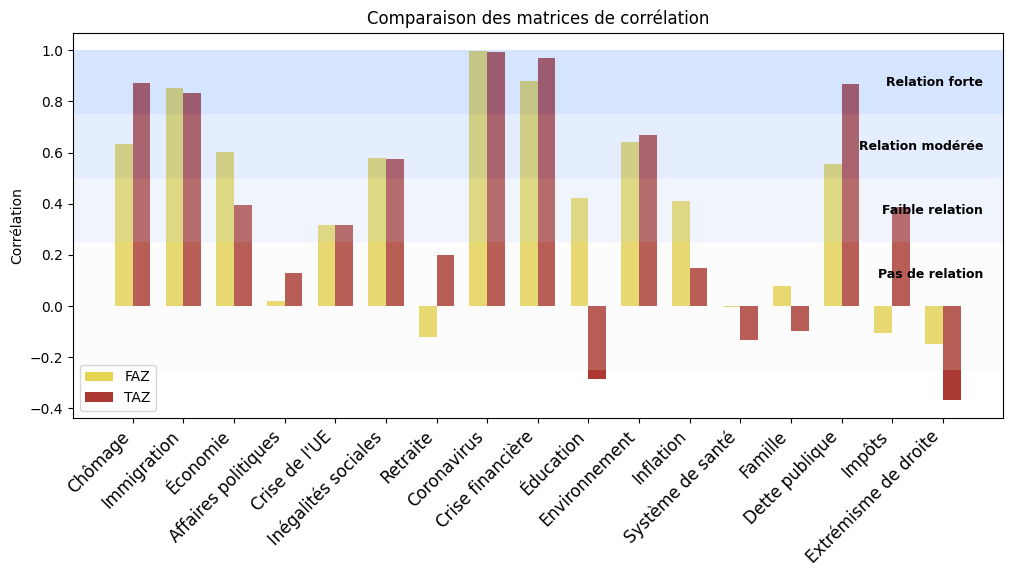

In [87]:


# Création des indices sous forme de catégories
indices = np.arange(len(corr_df))
width = 0.35  

# actual data
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(indices - width/2, corr_df["FAZ"], width=width, label="FAZ", color='#E5D352') 
ax.bar(indices + width/2, corr_df["TAZ"], width=width, label="TAZ", color='#AC3931')   

# zones de corrélation
ax.axhspan(-0.25, 0.25, facecolor='#f0f0f0', alpha=0.2)
ax.axhspan(0.25, 0.5, facecolor='#d0e1f9', alpha=0.3)
ax.axhspan(0.5, 0.75, facecolor='#a6c8ff', alpha=0.3)
ax.axhspan(0.75, 1.0, facecolor='#7aaaff', alpha=0.3)


# Ajouter corrélations
ax.text(len(indices) - 0.2, 0.125, 'Pas de relation', va='center', ha='right', fontsize=9, fontweight='bold')
ax.text(len(indices) - 0.2, 0.375, 'Faible relation', va='center', ha='right', fontsize=9, fontweight='bold')
ax.text(len(indices) - 0.2, 0.625, 'Relation modérée', va='center', ha='right', fontsize=9, fontweight='bold')
ax.text(len(indices) - 0.2, 0.875, 'Relation forte', va='center', ha='right', fontsize=9, fontweight='bold')


ax.set_xticks(indices)
ax.set_xticklabels(corr_df.index, fontsize=12,rotation=45,ha="right")  # Affichage des indices distincts

ax.set_ylabel("Corrélation")
ax.set_title("Comparaison des matrices de corrélation")
ax.legend()
plt.savefig('report/images/article_sondages_corr.pdf',bbox_inches='tight')

plt.show()


### Fisher's Test pour déterminer l'indépendance des variables

In [49]:
for idx in keywords_fr.keys():
    import scipy.stats as stats 
    df_test = dfs_faz_all[idx].copy().reset_index()
    df_test['survey'] = df_survey.reset_index()[idx]
    df_test = df_test.dropna()
    print(keywords_fr[idx])
    #print(df_test[[idx,'survey']])
    print(stats.fisher_exact(df_test).pvalue)
    print("---------------")

Retraite
0.211
---------------
Inflation
1.0
---------------
Impôts
0.6495
---------------
Économie
0.9522
---------------
Chômage
0.1739
---------------
Environnement
0.3889
---------------
Famille
0.3451
---------------
Système de santé
1.0
---------------
Sécurité intérieure
0.9171
---------------
Affaires politiques
0.1326
---------------
Éducation
0.8289
---------------
Asile
0.7309
---------------
Immigration
0.7837
---------------
Crise de l'UE
0.9557
---------------
Dette publique
0.6097
---------------
Extrémisme de droite
0.6065
---------------
Inégalités sociales
1.0
---------------
Crise financière
0.4324
---------------
Coronavirus
0.9572
---------------


np.float64(0.9651569044173717)

In [18]:
df_survey

# copy the data 
df_max_scaled = df_survey.copy() 
  
# apply normalization techniques 
for column in df_max_scaled.columns: 
    if column == 'Year':
        pass
    df_max_scaled[column] = df_max_scaled[column]  / df_max_scaled[column].abs().max() 
      
# view normalized data 
display(df_max_scaled) 


,14,54,13,134,27,15,77,1,55,66,30,5,117,20,10,23,19,58,53,56
Year,,,,,,,,,,,,,,,,,,,,
2000,0.754530,0.058254,0.088108,0.000000,0.786906,0.063331,0.080150,0.544819,0.008422,0.371627,0.118511,0.037210,0.000000,0.160332,0.870582,0.389684,0.272857,1.000000,0.464232,0.089133
2001,0.782928,0.043825,0.214002,0.000000,0.612339,0.057621,0.082605,0.368165,0.071735,0.328075,0.167140,0.044381,0.000000,0.222331,0.439152,0.546123,0.342911,0.618099,0.309391,0.057810
2002,0.913608,0.025733,0.347875,0.000000,0.541253,0.027394,0.060582,0.120611,0.044937,0.272695,0.199523,0.037765,0.000000,0.116334,0.660325,0.115830,0.266607,0.045488,0.085379,0.142042
2003,0.853681,0.007594,0.468369,0.000000,0.671002,0.008566,0.064996,0.388593,0.000244,0.409794,0.112771,0.021607,0.000000,0.486119,0.969802,0.033640,0.163720,0.012849,0.027601,0.282197
2004,0.867219,0.014218,0.373947,0.000000,0.704377,0.000000,0.091214,0.296435,0.003893,0.306571,0.178550,0.032176,0.000000,0.717214,0.573212,0.044714,0.208092,0.033416,0.067536,0.267799
2005,1.000000,0.007435,0.250603,0.000000,0.519557,0.009288,0.080244,0.148064,0.001907,0.187113,0.131167,0.051829,0.000000,0.109979,0.317605,0.035848,0.189001,0.015479,0.007130,0.227543
2006,0.908974,0.018818,0.165771,0.000000,0.444690,0.011403,0.118735,0.255987,0.001126,0.002263,0.245443,0.067834,0.000000,1.000000,0.763105,0.080487,0.412141,0.032653,0.000000,0.189378
2007,0.716718,0.021765,0.131267,0.000000,0.538532,0.175145,0.331050,0.373338,0.004473,0.419100,0.399417,0.180584,0.000000,0.656268,0.714469,0.160475,0.926625,0.050896,0.000000,0.139975
2008,0.441356,0.020264,0.278027,0.000000,0.750327,0.081818,0.544455,0.367905,0.001627,0.303247,0.561698,0.443485,0.631933,0.329729,1.000000,0.311066,0.617744,0.033224,0.000000,0.104614


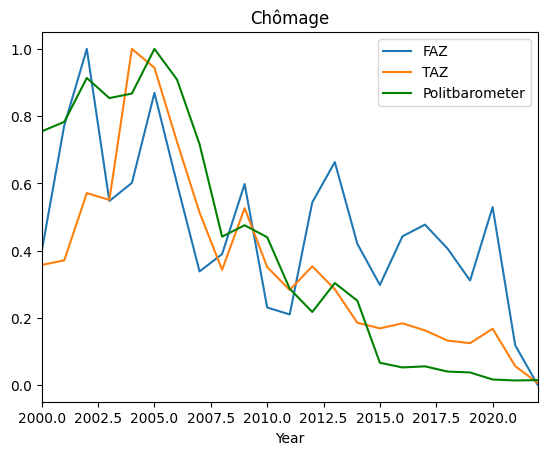

In [19]:
question_code = 14
ax = dfs_faz_all[question_code].plot(label = "FAZ")
dfs_taz_all[question_code].plot(ax=ax, label = "TAZ")
#df_survey[58] *= 10

df_max_scaled[question_code].plot(label = "Politbarometer",color='green')
plt.xlim(2000,2022)
plt.title(keywords_fr[question_code])
plt.legend()

In [96]:
df_survey[58]

Year
2000    0.040633
2001    0.021817
2002    0.002202
2003    0.000734
2004    0.001968
2005    0.001268
2006    0.001868
2007    0.002869
2008    0.001902
2009    0.002135
2010    0.000801
2011    0.006172
2012    0.005838
2013    0.005638
2014    0.005971
2015    0.010909
2016    0.022818
2017    0.014045
2018    0.023118
2019    0.028323
2020    0.015112
2021    0.005238
2022    0.003803
Name: 58, dtype: float64